# Retail customer analysis

Explore the customer data before building the churn model.

I'll check data quality, churn rates, RFM segments, country distribution,
and unusual spending patterns.

Input: `data/staged/customer_rfm_final.csv`, exported from
`export.customer_rfm_final` in SQL Server.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Load and inspect the data

In [14]:
df = pd.read_csv(
    "../data/staged/customer_rfm_final.csv",
    encoding="utf-8-sig",
    dtype={"customer_id": "string", "rfm_score": "string"}
)

df.columns = df.columns.str.strip()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 5,285
Columns: 8


,customer_id,country,recency_days,frequency,monetary,rfm_score,rfm_segment,churned
0,12346,United Kingdom,236,12,77556.46,355,Needs Attention,1
1,12347,Iceland,40,6,4114.18,445,Champions,0
2,12348,Finland,159,4,1709.40,344,Needs Attention,0
3,12349,Italy,318,3,2671.14,234,Needs Attention,0
4,12350,Norway,221,1,334.40,322,Needs Attention,1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5285 entries, 0 to 5284
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   5285 non-null   string 
 1   country       5285 non-null   object 
 2   recency_days  5285 non-null   int64  
 3   frequency     5285 non-null   int64  
 4   monetary      5285 non-null   float64
 5   rfm_score     5285 non-null   string 
 6   rfm_segment   5285 non-null   object 
 7   churned       5285 non-null   int64  
dtypes: float64(1), int64(3), object(2), string(2)
memory usage: 330.4+ KB


## Check data quality

Each row should represent one customer, with no missing feature values.

In [16]:
df.isna().sum()

customer_id     0
country         0
recency_days    0
frequency       0
monetary        0
rfm_score       0
rfm_segment     0
churned         0
dtype: int64

In [17]:
print("Duplicate customers:", df["customer_id"].duplicated().sum())
print("Churn values:", df["churned"].unique())

df[["recency_days", "frequency", "monetary"]].describe()

Duplicate customers: 0
Churn values: [1 0]


,recency_days,frequency,monetary
count,5285.000000,5285.000000,5285.000000
mean,208.208704,5.748155,2706.884443
std,175.359480,11.467013,12533.174438
min,0.000000,1.000000,2.900000
25%,49.000000,1.000000,323.860000
50%,165.000000,3.000000,803.880000
75%,328.000000,6.000000,2119.270000
max,649.000000,309.000000,484615.100000


## Churn distribution

A customer is labeled churned if they made no purchase during the
90-day window after the cutoff.

Churn rate: 56.7%


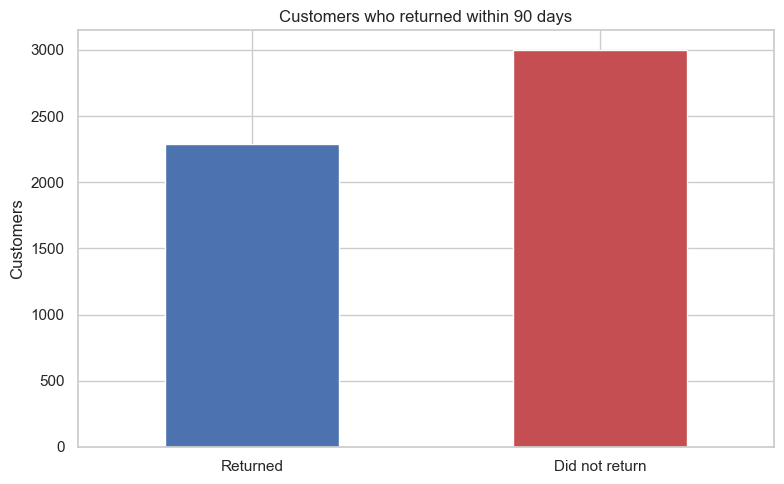

In [18]:
churn_counts = df["churned"].value_counts().reindex([0, 1], fill_value=0)
churn_rate = df["churned"].mean()

print(f"Churn rate: {churn_rate:.1%}")

ax = churn_counts.plot.bar(color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Returned", "Did not return"], rotation=0)
ax.set_xlabel("")
ax.set_ylabel("Customers")
ax.set_title("Customers who returned within 90 days")

plt.tight_layout()
plt.show()

## RFM segments

Compare the size, spending, and churn rate of the SQL-based segments.
Monetary values represent purchases before the cutoff.

In [19]:
segment_summary = (
    df.groupby("rfm_segment")
    .agg(
        customers=("customer_id", "size"),
        average_spend=("monetary", "mean"),
        median_spend=("monetary", "median"),
        churn_rate=("churned", "mean")
    )
    .sort_values("customers", ascending=False)
)

segment_summary.round(2)

,customers,average_spend,median_spend,churn_rate
rfm_segment,,,,
Needs Attention,2283,1285.99,775.32,0.62
Champions,1181,8457.49,3881.80,0.19
Lost,995,238.78,219.40,0.86
New Customers,472,532.97,386.68,0.52
At Risk,354,2521.26,1383.41,0.69


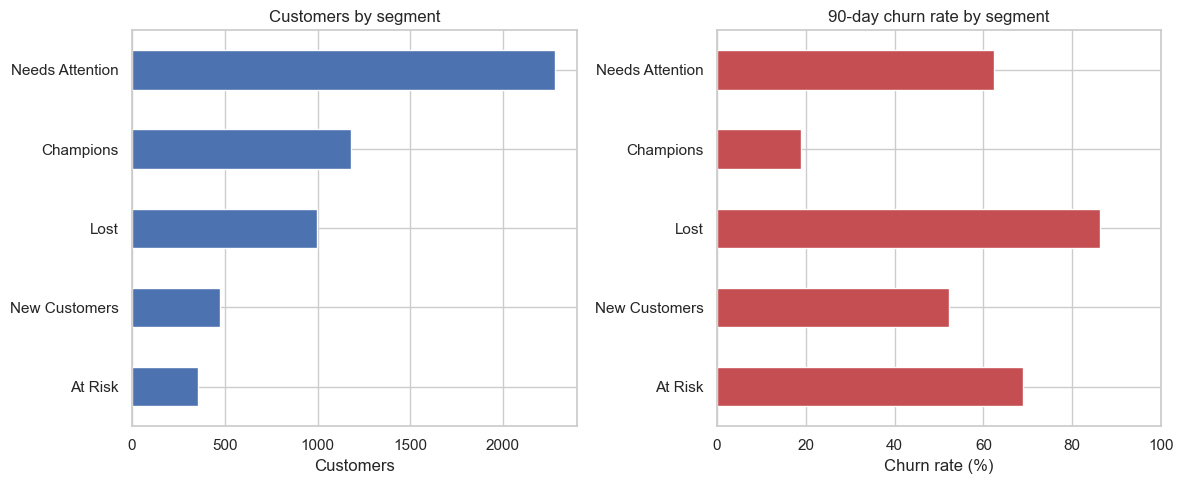

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

segment_summary["customers"].plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_title("Customers by segment")
axes[0].set_xlabel("Customers")
axes[0].set_ylabel("")
axes[0].invert_yaxis()

(segment_summary["churn_rate"] * 100).plot.barh(
    ax=axes[1], color="#C44E52"
)
axes[1].set_title("90-day churn rate by segment")
axes[1].set_xlabel("Churn rate (%)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Purchase behavior

Check the spread of recency, frequency, and spending.
Large spending values may need a closer look before modeling.

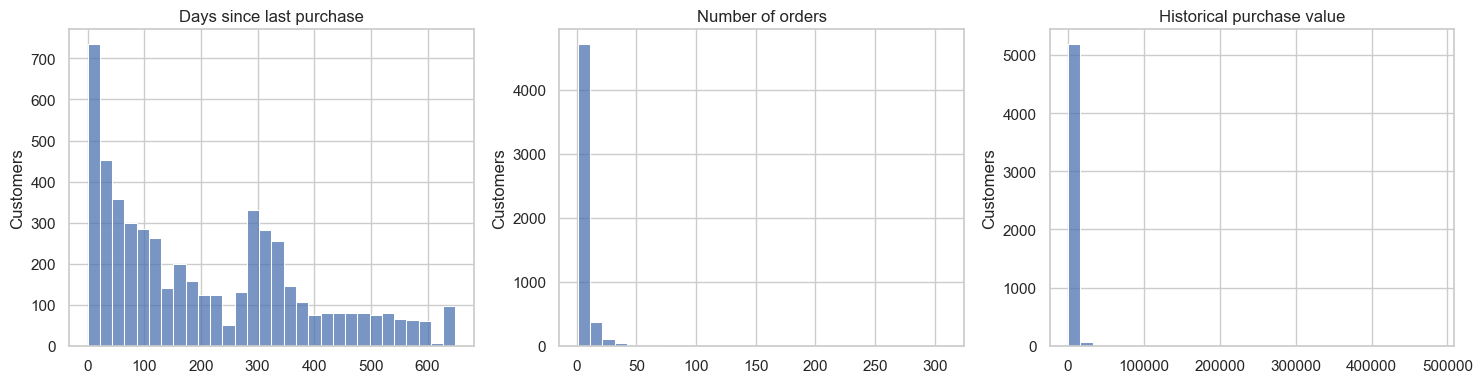

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = {
    "recency_days": "Days since last purchase",
    "frequency": "Number of orders",
    "monetary": "Historical purchase value"
}

for ax, (column, title) in zip(axes, features.items()):
    sns.histplot(data=df, x=column, bins=30, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [22]:
df.groupby("churned")[
    ["recency_days", "frequency", "monetary"]
].median().rename(index={0: "Returned", 1: "Did not return"})

,recency_days,frequency,monetary
churned,,,
Returned,67.0,5.0,1657.18
Did not return,287.0,2.0,496.75


## Country distribution

Check how much of the customer base comes from the UK.
Small country groups should be interpreted carefully.

UK share of customers: 0.0%


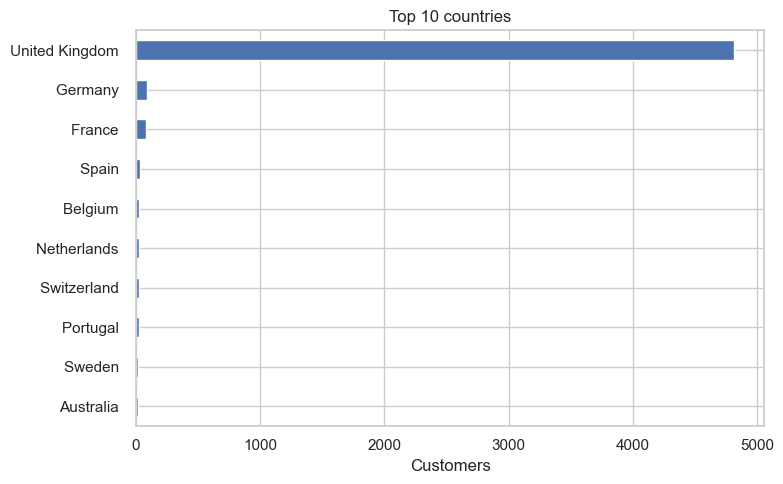

In [23]:
country_counts = df["country"].value_counts()
uk_share = df["country"].eq("United Kingdom").mean()

print(f"UK share of customers: {uk_share:.1%}")

ax = country_counts.head(10).sort_values().plot.barh(color="#4C72B0")
ax.set_title("Top 10 countries")
ax.set_xlabel("Customers")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## High-spending customers

Customer 12346 was flagged during the SQL checks. Compare this customer
with the largest purchase totals, then review the original invoices
and cancellations before drawing conclusions.

In [25]:
df.nlargest(10, "monetary")[
    ["customer_id", "frequency", "monetary", "rfm_segment", "churned"]
]

,customer_id,frequency,monetary,rfm_segment,churned
5117,18102,112,484615.10,Champions,0
2040,14646,120,426699.12,Champions,0
1593,14156,143,295425.08,Champions,0
2277,14911,309,234125.25,Champions,0
1182,13694,132,177354.83,Champions,0
4590,17511,50,143916.92,Champions,0
4542,17450,28,138883.84,Champions,0
65,12415,22,121631.72,Champions,0
2412,15061,116,119859.38,Champions,0
3856,16684,45,114372.71,Champions,0


In [26]:
df.loc[df["customer_id"] == "12346"]

,customer_id,country,recency_days,frequency,monetary,rfm_score,rfm_segment,churned
0,12346,United Kingdom,236,12,77556.46,355,Needs Attention,1


## Findings

Complete this section after running the notebook.

- Does the exported data match the SQL checks?
- Which segments have the highest churn rates, and how large are they?
- How do purchasing patterns differ between returning and non-returning customers?
- How skewed are frequency and spending?
- What needs further investigation before modeling?

Next: build and evaluate the churn classifier.